# Seat Changes without GRCs

What if GRC seats had been split proportionally based on votes? Set `SCENARIO` in the next cell, then **Run All** to get the figures and tables for that scenario.

| Scenario | Rounding rule for fractional seats |
|---|---|
| `ProPAP` | PAP gets the rounded-up seat split |
| `AntiPAP` | PAP gets the rounded-down seat split |
| `ProWinner` | The actual winner of the GRC gets the rounded-up seat split |

Results are written to `<SCENARIO>_results/`.

In [113]:
# Choose scenario: 'ProPAP', 'AntiPAP' or 'ProWinner'
SCENARIO = 'ProWinner'  # Change this to 'ProPAP' or 'ProWinner' as needed


scenario_titles = {
    'ProPAP': 'Pro-PAP',
    'AntiPAP': 'Anti-PAP',
    'ProWinner': 'Pro-Winner',
}
assert SCENARIO in scenario_titles, "SCENARIO must be 'ProPAP', 'AntiPAP' or 'ProWinner'"
RESULTS_DIR = SCENARIO + '_results'

In [114]:
import pandas as pd
import math
import os

In [115]:
colors = {
    "People\'s Action Party": '#0000FF',  # Blue
    "Workers' Party": '#FF0000',  # Red
    "National Solidarity Party": '#00FF00',  # Green
    "Singapore Democratic Party": '#FFFF00',  # Yellow
    "Reform Party": '#FFA500',  # Orange
    "Singapore People's Party": '#800080',  # Purple
    "Progress Singapore Party": '#00FFFF',  # Cyan
    "People's Power Party": '#FF00FF',  # Magenta
    "Red Dot United": '#A52A2A',  # Brown
    "Singapore Democratic Alliance": '#808080',  # Gray
    "Singaporeans First": '#8B4513',  # SaddleBrown
    "Peoples Voice": '#FFD700',  # Gold
    "United People's Front": '#000000', # Black
    "Singapore Justice Party": '#FFC0CB',  # Pink
    "People's Alliance for Reform": '#FF7F50',  # Coral
    "Singapore United Party": '#4682B4',  # SteelBlue
    "Independent": '#3b3b3b'  # Gray

}

In [116]:
def allocate_grc_seats(parties, percentages, total_seats):
    """Allocate a GRC's seats proportionally using the largest-remainder
    (Hamilton) method, so the allocated seats ALWAYS sum to the GRC size.

    Each party first receives the whole-number part of its proportional
    share. The remaining seat(s) are then awarded one at a time according
    to the scenario:
      ProPAP    -> PAP has first claim on a leftover seat
      AntiPAP   -> PAP is last in line for leftover seats
      ProWinner -> the actual winner (highest vote share) has first claim
    Any further leftover seats go by largest fractional remainder.

    In a two-party GRC this reproduces the original ceil/floor behaviour,
    but unlike ceil/floor it conserves the total in 3+ party GRCs.
    """
    quotas = [total_seats * p / 100 for p in percentages]
    alloc = [math.floor(q) for q in quotas]
    remainders = [q - math.floor(q) for q in quotas]
    leftover = int(round(total_seats - sum(alloc)))
    n = len(parties)
    winner = max(range(n), key=lambda i: percentages[i])

    def priority(i):
        is_pap = parties[i] == "People's Action Party"
        if SCENARIO == 'ProPAP':
            return (0 if is_pap else 1, -remainders[i])
        elif SCENARIO == 'AntiPAP':
            return (1 if is_pap else 0, -remainders[i])
        else:  # ProWinner
            return (0 if i == winner else 1, -remainders[i])

    order = sorted(range(n), key=priority)
    for k in range(leftover):
        alloc[order[k]] += 1
    return alloc

In [117]:
GE_years = [1988,1991,1997,2001,2006,2011,2015,2020,2025]

os.makedirs(RESULTS_DIR, exist_ok=True)

all_seat_changes=pd.DataFrame(columns = ['Party','Seat Change','Year'])


for year in GE_years:

    ## Set up dataframe
    file_path = 'Actual_results/'+ str(year)+'-Table 1.csv'
    df = pd.read_csv(file_path)

    # Remove empty rows and columns
    df = df.dropna(how='all').dropna(axis=1, how='all')

    df.columns = df.iloc[0]
    df = df[1:]

    # Reset the index
    df.reset_index(drop=True, inplace=True)


    ## Data Cleaning

    # Fill up rows, which dont have Constituency and Seats, with the respective constituency and seats
    for i in range(1, len(df)):
        if pd.isna(df.at[i, df.columns[0]]):

            df.iloc[i][0] = df.iloc[i-1][0]
            df.iloc[i][1] = df.iloc[i-1][1]

    # Remove SMCs
    df = df[df['Seats'] != '1']

    # Remove walkovers (if no vote percentage)
    df = df.dropna(subset='%')

    df['%']=df['%'].str[:5]
    df['%']=df['%'].astype(float)
    df['Seats']=df['Seats'].astype(int)


    # Remove bug substring
    df['Party']=df['Party'].str.replace('\xa0','',regex=False)

    df.reset_index(drop=True, inplace=True)

    ## Calculations

    # Calculate Old Seats
    df['Old Seats']=0
    for i in range(0, len(df)):
        total_seats = df.iloc[i]['Seats']
        vote_percentage=df.iloc[i]['%']
        if df.iloc[i]['%']> 50:
            df.at[i,'Old Seats'] = total_seats
        else:
            df.at[i,'Old Seats'] = 0

    # Calculate new seats (scenario-dependent), conserving each GRC's seat total
    df['New Seats']=0
    for division, grp in df.groupby(df.columns[0], sort=False):
        parties = grp['Party'].tolist()
        pcts = grp['%'].tolist()
        size = int(grp['Seats'].iloc[0])
        alloc = allocate_grc_seats(parties, pcts, size)
        for j, seats in zip(grp.index, alloc):
            df.at[j, 'New Seats'] = seats

    ## Calculate Seat Changes
    df['Seat Change']=0
    for i in range(0, len(df)):
        df.at[i,'Seat Change'] = df.iloc[i]['New Seats']-df.iloc[i]['Old Seats']

    df.to_csv(RESULTS_DIR+'/'+str(year)+'_results.csv',index=False)

    ## Collate Seat Changes
    seat_changes = df.groupby('Party')['Seat Change'].sum().reset_index()
    seat_changes['Year']=year

    all_seat_changes=pd.concat([all_seat_changes,seat_changes],ignore_index=True)

all_seat_changes

C:\Users\lintang\AppData\Local\Temp\ipykernel_9064\3405950673.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[i][0] = df.iloc[i-1][0]
C:\Users\lintang\AppData\Local\Temp\ipykernel_9064\3405950673.py:30: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment i

,Party,Seat Change,Year
0,National Solidarity Party,1,1988
1,People's Action Party,-7,1988
2,Singapore Democratic Party,1,1988
3,Singapore Justice Party,0,1988
4,United People's Front,0,1988
5,Workers' Party,5,1988
6,National Solidarity Party,2,1991
7,People's Action Party,-4,1991
8,Singapore Justice Party,0,1991
9,Workers' Party,2,1991


In [118]:
all_seat_changes.to_csv(RESULTS_DIR+'/all_results.csv',index=False)

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

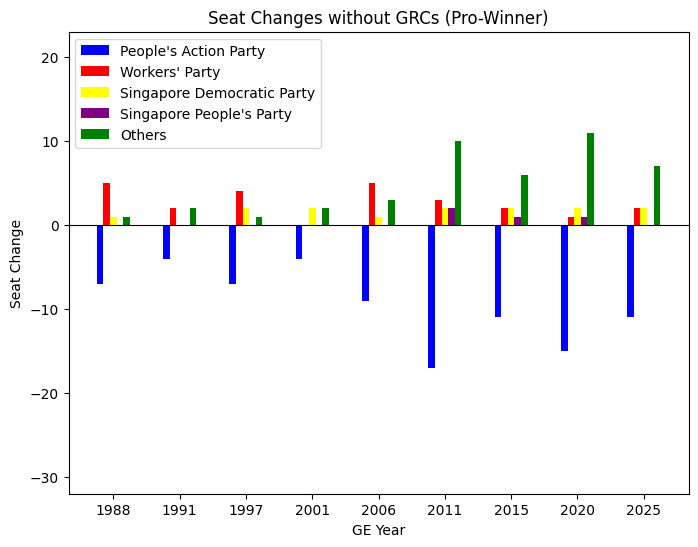

In [123]:
data = all_seat_changes

# Group all parties except People's Action Party and Workers' Party under "Others"
data['Party Grouped'] = data['Party'].apply(lambda x: x if x in ["People's Action Party", "Workers' Party", "Singapore Democratic Party", "Singapore People's Party"] else 'Others')

# Summarize the seat changes by the new grouping
grouped_summary = data.groupby(['Year', 'Party Grouped'])['Seat Change'].sum().reset_index()

# Adjust the grouped bar chart to ensure matching data lengths
plt.figure(figsize=(8, 6))

# Define the width of each bar
bar_width = 0.10

# Filter data for each group
pap_data = grouped_summary[grouped_summary['Party Grouped'] == "People's Action Party"]
wp_data = grouped_summary[grouped_summary['Party Grouped'] == "Workers' Party"]
sdp_data = grouped_summary[grouped_summary['Party Grouped'] == "Singapore Democratic Party"]
spp_data = grouped_summary[grouped_summary['Party Grouped'] == "Singapore People's Party"]
others_data = grouped_summary[grouped_summary['Party Grouped'] == 'Others']

# Generate positions for the bars
years = sorted(grouped_summary['Year'].unique())
positions = {year: index for index, year in enumerate(years)}

# Adjust positions for each group
pap_positions = [positions[year] - 2*bar_width for year in pap_data['Year']]
wp_positions = [positions[year] - bar_width for year in wp_data['Year']]
sdp_positions = [positions[year] for year in sdp_data['Year']]
spp_positions = [positions[year] + bar_width for year in spp_data['Year']]
others_positions = [positions[year] + 2*bar_width for year in others_data['Year']]

# Plotting bars for each party group with specified colors
plt.bar(pap_positions, pap_data['Seat Change'], color=colors["People\'s Action Party"], width=bar_width, label="People's Action Party")
plt.bar(wp_positions, wp_data['Seat Change'], color=colors["Workers' Party"], width=bar_width, label="Workers' Party")
plt.bar(sdp_positions, sdp_data['Seat Change'], color=colors["Singapore Democratic Party"], width=bar_width, label= "Singapore Democratic Party")
plt.bar(spp_positions, spp_data['Seat Change'], color=colors["Singapore People's Party"], width=bar_width, label= "Singapore People's Party")
plt.bar(others_positions, others_data['Seat Change'], color='green', width=bar_width, label='Others')

# Set the x-axis to show only the election years
plt.title('Seat Changes without GRCs ('+scenario_titles[SCENARIO]+')')
plt.xlabel('GE Year')
plt.ylabel('Seat Change')
plt.xticks(range(len(years)), years)  # Set positions for x-axis labels
plt.ylim(-32,23)  # Set positions for y-axis labels
plt.legend()
plt.grid(False)
plt.axhline(y=0, color='black', linewidth=0.8)  # Add the y=0 horizontal line
plt.show()

In [121]:
## Look at specific year's results

year = 2025

df = pd.read_csv(RESULTS_DIR+'/'+str(year)+'_results.csv')

df

,Division,Seats,Voters,Rejected,Party,Candidate(s),Votes,%,Swing,Margins,Old Seats,New Seats,Seat Change
0,Aljunied GRC,5,"133,451","1,341",Workers' Party,Pritam Singh\nSylvia Lim\nGerald Giam\nFadli F...,"79,254",59.71,0.27,19.42%,5,3,-2
1,Aljunied GRC,5,NaN,NaN,People's Action Party,Chan Hui Yuh\nAdrian Ang\nFaisal Abdul Aziz\nJ...,"53,471",40.29,0.27,NaN,0,2,2
2,Ang Mo Kio GRC,5,"150,312","4,399",People's Action Party,Lee Hsien Loong\nDarryl David\nJasmin Lau\nVic...,"115,562",78.95,7.04,68.11%,5,4,-1
3,Ang Mo Kio GRC,5,NaN,NaN,Singapore United Party,Vincent Ng\nNigel Ng\nNoraini Yunus\nRidhuan C...,"15,874",10.84,NaN,NaN,0,1,1
4,Ang Mo Kio GRC,5,NaN,NaN,People's Power Party,Heng Zheng Dao\nMartinn Ho\nSamuel Lee\nWillia...,"14,929",10.21,NaN,NaN,0,0,0
5,Bishan–Toa Payoh GRC,4,"90,020","2,092",People's Action Party,Chee Hong Tat\nCai Yinzhou\nElysa Chen\nSaktia...,"66,455",75.18,7.95,50.36%,4,4,0
6,Bishan–Toa Payoh GRC,4,NaN,NaN,Singapore People's Party,Steve Chia\nMelvyn Chiu\nLim Rui Xian\nMuhamma...,"21,944",24.82,7.95,NaN,0,0,0
7,Chua Chu Kang GRC,4,"87,677","1,191",People's Action Party,Tan See Leng\nChoo Pei Ling\nJeffrey Siow\nZhu...,"55,140",63.60,4.96,27.20%,4,3,-1
8,Chua Chu Kang GRC,4,NaN,NaN,Progress Singapore Party,A'bas Kasmani\nWendy Low\nLawrence Pek\nS Nall...,"31,562",36.40,4.96,NaN,0,1,1
9,East Coast GRC,5,"137,141","1,570",People's Action Party,Edwin Tong\nDinesh Vasu Dash\nHazlina Abdul Ha...,"80,105",58.73,5.34,17.46%,5,3,-2


In [122]:
# Look at specific year's seat change for all parties

df = all_seat_changes
year = 2025

df = df[df['Year'] == year]

df

,Party,Seat Change,Year,Party Grouped
47,National Solidarity Party,0,2025,Others
48,People's Action Party,-11,2025,People's Action Party
49,People's Alliance for Reform,0,2025,Others
50,People's Power Party,0,2025,Others
51,Progress Singapore Party,3,2025,Others
52,Red Dot United,2,2025,Others
53,Singapore Democratic Alliance,1,2025,Others
54,Singapore Democratic Party,2,2025,Singapore Democratic Party
55,Singapore People's Party,0,2025,Singapore People's Party
56,Singapore United Party,1,2025,Others
